In [1]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [2]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

data_dir = "dataset"

In [3]:
import os

for folder in os.listdir(data_dir):
    print(folder, ":", len(os.listdir(os.path.join(data_dir, folder))))

disgust : 100
neutral : 100
happy : 100
sad : 100
surprise : 100
angry : 100
fear : 100


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

data_dir = "dataset"

images = []
labels = []
label_names = []

for label, emotion in enumerate(os.listdir(data_dir)):
    label_names.append(emotion)
    path = os.path.join(data_dir, emotion)

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (96, 96))

        images.append(img)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Loaded:", X.shape)

Loaded: (700, 96, 96)


In [5]:
def apply_filter(img):
    return cv2.GaussianBlur(img, (3,3), 0)


In [6]:
def normalize(img):
    return img / 255.0

In [7]:

def histogram_equalization(img):
    return cv2.equalizeHist(img)

In [8]:
processed_images = []

for img in X:
    img1 = apply_filter(img)
    img1 = histogram_equalization(img)
    img3 = normalize(img)

    processed_images.append(img3)

X_processed = np.array(processed_images)

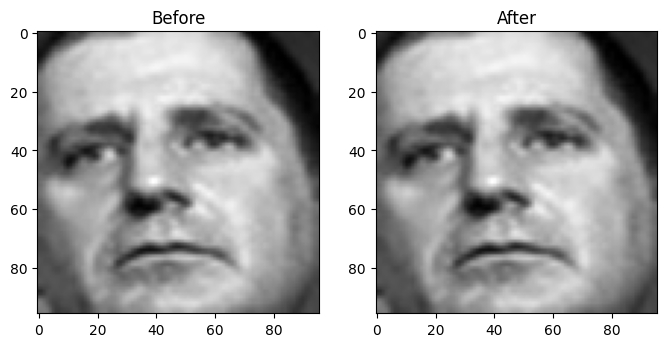

In [9]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X[500], cmap='gray')
plt.title("Before")

plt.subplot(1,2,2)
plt.imshow(X_processed[500], cmap='gray')
plt.title("After")

plt.show()

# **Facial landmarks detection**

In [10]:
pip install -q --upgrade mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.8 MB/s eta 0:00:00


In [11]:
!wget -O face_landmarker.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [35]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import glob



base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1,
    min_face_detection_confidence=0.1

)

detector = vision.FaceLandmarker.create_from_options(options)



MOUTH_OUTLINE = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291,
                     308, 324, 318, 402, 317, 14, 87, 178, 88, 95, 78]

LEFT_EYE = [33, 7, 163, 144, 145, 153, 154, 155, 133,
            173, 157, 158, 159, 160, 161, 246]

RIGHT_EYE = [362, 382, 381, 380, 374, 373, 390, 249, 263,
              466, 388, 387, 386, 385, 384, 398]

features_to_keep = [MOUTH_OUTLINE, LEFT_EYE, RIGHT_EYE]
print("Processing images...")
processed_images = []

for img in X_processed:
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

    detection_result = detector.detect(mp_image)

    if not detection_result.face_landmarks:
        processed_images.append(img)
        continue

    face_landmarks = detection_result.face_landmarks[0]
    mask = np.zeros(img_rgb.shape[:2], dtype=np.uint8)

    for feature in features_to_keep:
        points = []
        for idx in feature:
            landmark = face_landmarks[idx]
            x = int(landmark.x * img.shape[1])
            y = int(landmark.y * img.shape[0])
            points.append([x, y])

        points = np.array(points, dtype=np.int32)
        cv2.fillPoly(mask, [points], 255)

    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)

    final_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    final_img = cv2.cvtColor(final_img, cv2.COLOR_RGB2GRAY)
    processed_images.append(final_img)

print("Done")
processed_images = np.array(processed_images)

Processing images...
Done


In [36]:
processed_images.shape

(700, 96, 96)

Text(0.5, 1.0, 'After')

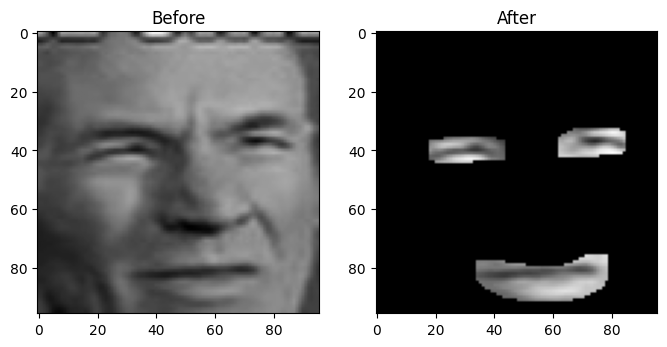

In [38]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X[10], cmap='gray')
plt.title("Before")

plt.subplot(1,2,2)
plt.imshow(processed_images[10], cmap='gray')
plt.title("After")